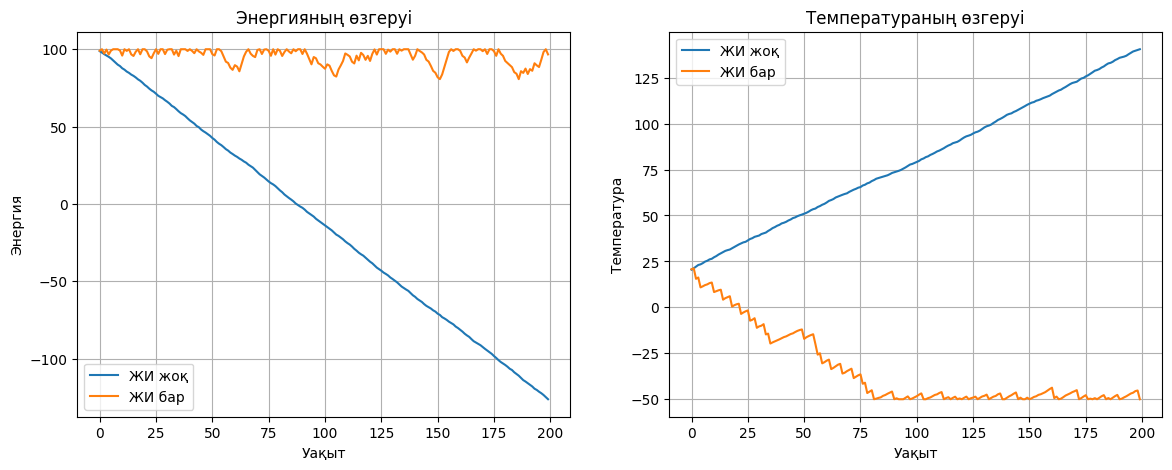

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt


INITIAL_ENERGY = 100.0
INITIAL_TEMPERATURE = 20.0
INITIAL_HEALTH = 1.0

def calculate_reward(energy, temperature, health):
    reward = 0

    if energy > 30:
        reward += 1
    else:
        reward -= 3

    if 0 <= temperature <= 35:
        reward += 2
    else:
        reward -= 5

    if health > 0.7:
        reward += 2
    else:
        reward -= 10

    return reward


def step(action, energy, temperature, health):

    energy -= random.uniform(0.8, 1.5)
    temperature += random.uniform(0.3, 0.9)
    health -= random.uniform(0.0, 0.02)


    if action == 1:
        energy += 6
    elif action == 2:
        temperature -= 6
        energy -= 2
    elif action == 3:
        energy += 4
        health += 0.05


    energy = max(0, min(100, energy))
    temperature = max(-50, min(100, temperature))
    health = max(0, min(1, health))

    return energy, temperature, health

STEPS = 200

energy_ai = []
energy_no_ai = []

temp_ai = []
temp_no_ai = []


e_ai, t_ai, h_ai = INITIAL_ENERGY, INITIAL_TEMPERATURE, INITIAL_HEALTH
e_na, t_na, h_na = INITIAL_ENERGY, INITIAL_TEMPERATURE, INITIAL_HEALTH

for _ in range(STEPS):

    e_na -= random.uniform(0.8, 1.5)
    t_na += random.uniform(0.3, 0.9)

    energy_no_ai.append(e_na)
    temp_no_ai.append(t_na)


    action = random.randint(0, 3)
    e_ai, t_ai, h_ai = step(action, e_ai, t_ai, h_ai)

    energy_ai.append(e_ai)
    temp_ai.append(t_ai)


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(energy_no_ai, label="ЖИ жоқ")
plt.plot(energy_ai, label="ЖИ бар")
plt.xlabel("Уақыт")
plt.ylabel("Энергия")
plt.title("Энергияның өзгеруі")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(temp_no_ai, label="ЖИ жоқ")
plt.plot(temp_ai, label="ЖИ бар")
plt.xlabel("Уақыт")
plt.ylabel("Температура")
plt.title("Температураның өзгеруі")
plt.legend()
plt.grid()

plt.show()

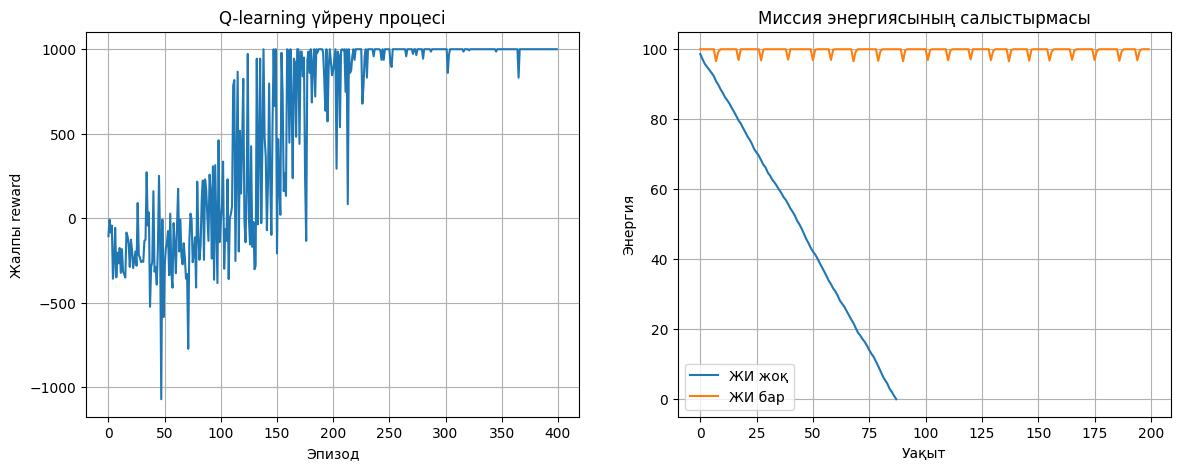

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt


ENERGY_MAX = 100
TEMP_MIN = -50
TEMP_MAX = 100

ACTIONS = 4

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

EPISODES = 400
STEPS = 200


def discretize_energy(e):
    return min(int(e // 10), 9)

def discretize_temp(t):
    return min(max(int((t + 50) // 15), 0), 9)

def discretize_health(h):
    return min(int(h * 10), 9)

# Q-table
Q = np.zeros((10, 10, 10, ACTIONS))


def reward_function(energy, temp, health):
    r = 0

    if energy > 30:
        r += 1
    else:
        r -= 3

    if 0 <= temp <= 35:
        r += 2
    else:
        r -= 5

    if health > 0.7:
        r += 2
    else:
        r -= 10

    return r


def step(action, energy, temp, health):

    energy -= random.uniform(0.8, 1.5)
    temp += random.uniform(0.3, 0.9)
    health -= random.uniform(0.0, 0.02)


    if action == 1:
        energy += 6
    elif action == 2:
        temp -= 6
        energy -= 2
    elif action == 3:
        energy += 4
        health += 0.05

    energy = np.clip(energy, 0, ENERGY_MAX)
    temp = np.clip(temp, TEMP_MIN, TEMP_MAX)
    health = np.clip(health, 0, 1)

    return energy, temp, health


episode_rewards = []

for ep in range(EPISODES):
    energy = 100.0
    temp = 20.0
    health = 1.0
    total_reward = 0

    for _ in range(STEPS):
        s = (
            discretize_energy(energy),
            discretize_temp(temp),
            discretize_health(health)
        )


        if random.random() < epsilon:
            action = random.randint(0, ACTIONS - 1)
        else:
            action = np.argmax(Q[s])


        energy2, temp2, health2 = step(action, energy, temp, health)
        r = reward_function(energy2, temp2, health2)

        s2 = (
            discretize_energy(energy2),
            discretize_temp(temp2),
            discretize_health(health2)
        )


        Q[s + (action,)] += alpha * (
            r + gamma * np.max(Q[s2]) - Q[s + (action,)]
        )

        energy, temp, health = energy2, temp2, health2
        total_reward += r

        if energy <= 0 or health <= 0:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon * epsilon_decay, epsilon_min)


def run(ai=True):
    energy = 100.0
    temp = 20.0
    health = 1.0
    energies = []

    for _ in range(STEPS):
        if ai:
            s = (
                discretize_energy(energy),
                discretize_temp(temp),
                discretize_health(health)
            )
            action = np.argmax(Q[s])
        else:
            action = 0

        energy, temp, health = step(action, energy, temp, health)
        energies.append(energy)

        if energy <= 0 or health <= 0:
            break

    return energies

energy_ai = run(ai=True)
energy_no_ai = run(ai=False)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(episode_rewards)
plt.title("Q-learning үйрену процесі")
plt.xlabel("Эпизод")
plt.ylabel("Жалпы reward")
plt.grid()

plt.subplot(1,2,2)
plt.plot(energy_no_ai, label="ЖИ жоқ")
plt.plot(energy_ai, label="ЖИ бар")
plt.title("Миссия энергиясының салыстырмасы")
plt.xlabel("Уақыт")
plt.ylabel("Энергия")
plt.legend()
plt.grid()

plt.show()